In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score , classification_report ,confusion_matrix,roc_auc_score,roc_curve,ConfusionMatrixDisplay

In [5]:
df = pd.read_csv('churn_Modelling.csv')

In [6]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.shape

(10000, 14)

In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


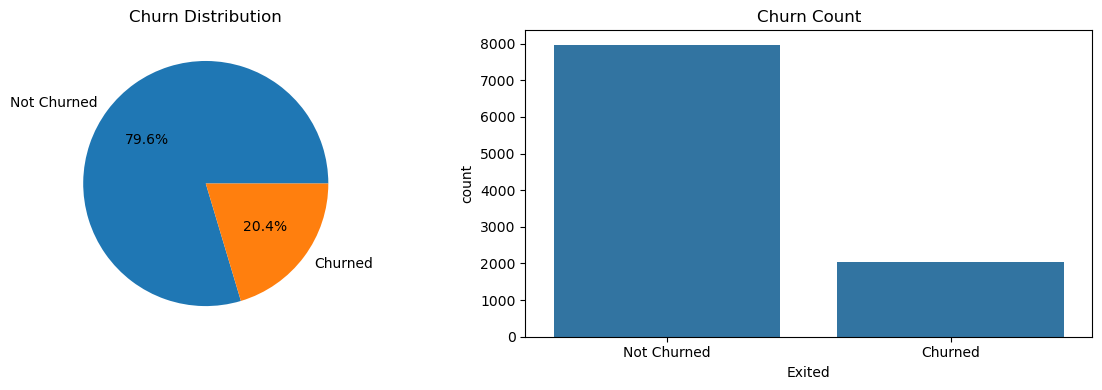

Churn Rate: 20.37 %


In [10]:

counts = df['Exited'].value_counts()
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.pie(counts, labels=['Not Churned', 'Churned'], autopct='%1.1f%%')
plt.title('Churn Distribution')


plt.subplot(1,2,2)
sns.countplot(x='Exited', data=df)
plt.xticks([0,1], ['Not Churned', 'Churned'])
plt.title('Churn Count')

plt.tight_layout()
plt.show()

print("Churn Rate:", round(df['Exited'].mean()*100, 2), "%")

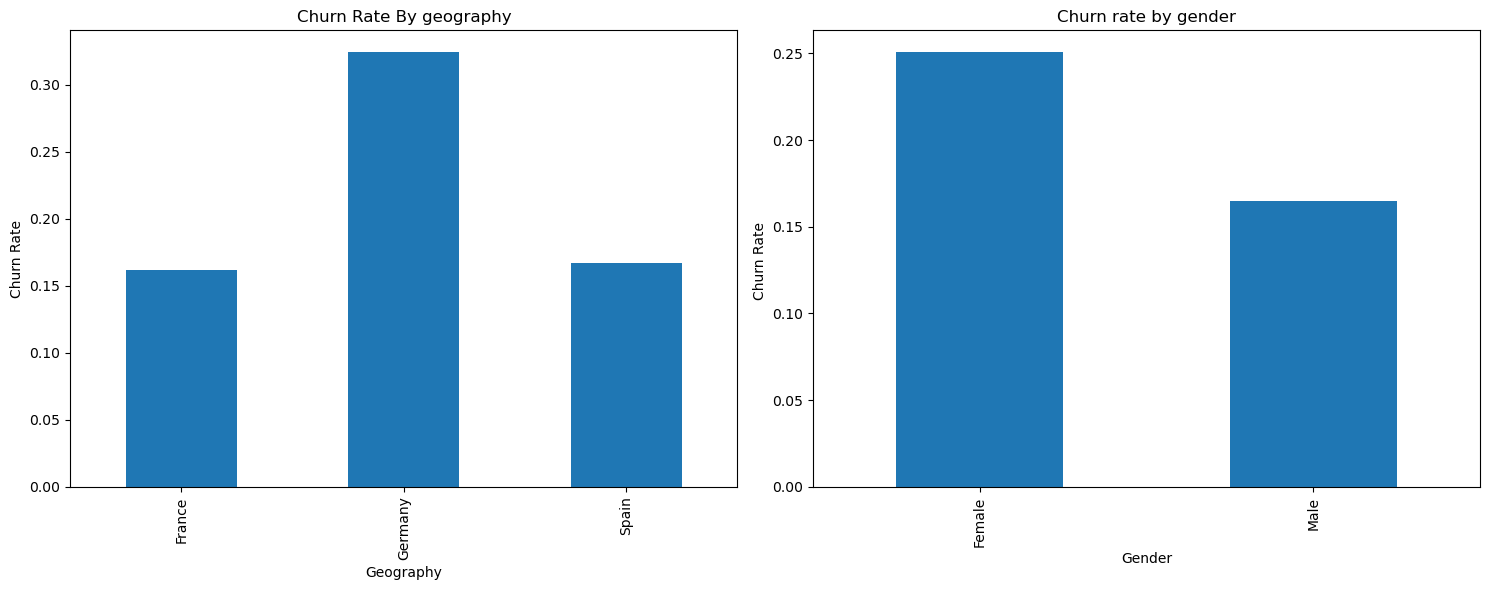

In [11]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
geo = df.groupby('Geography')['Exited'].mean()
geo.plot(kind='bar')
plt.title('Churn Rate By geography')
plt.ylabel('Churn Rate')

plt.subplot(1,2,2)
gender = df.groupby('Gender')['Exited'].mean()
gender.plot(kind='bar')
plt.title('Churn rate by gender')
plt.ylabel('Churn Rate ')
plt.tight_layout()
plt.show()

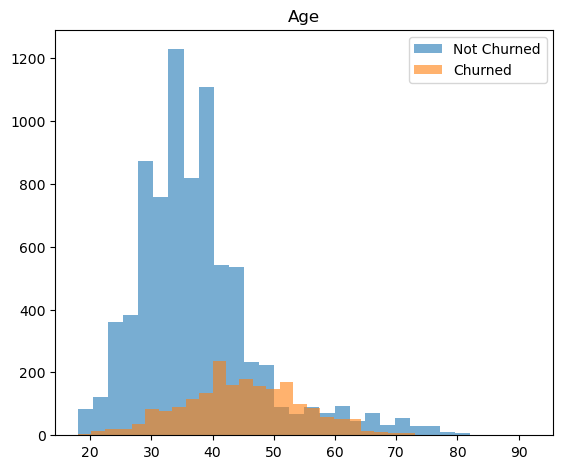

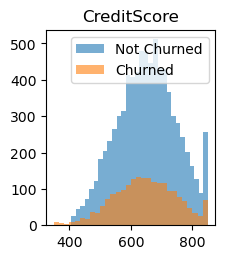

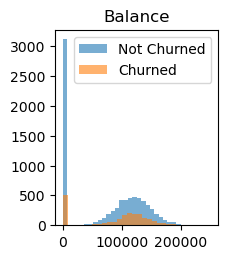

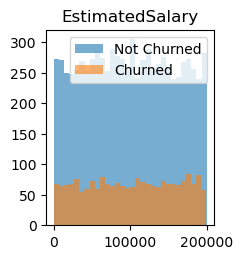

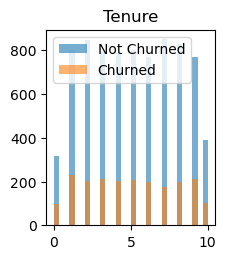

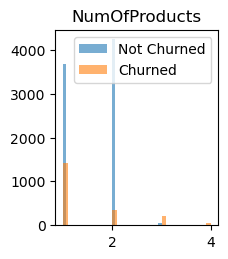

In [12]:
nums = ['Age','CreditScore','Balance','EstimatedSalary','Tenure','NumOfProducts']
plt.figure(figsize=(16,9))
for i ,col  in enumerate(nums):
    plt.subplot(2,3,i+1)
    plt.hist(df[df['Exited']==0][col],bins=30,alpha=0.6,label='Not Churned')
    plt.hist(df[df['Exited']==1][col],bins=30,alpha=0.6,label='Churned')
    plt.title(col)
    plt.legend()
    plt.tight_layout()
    plt.show()


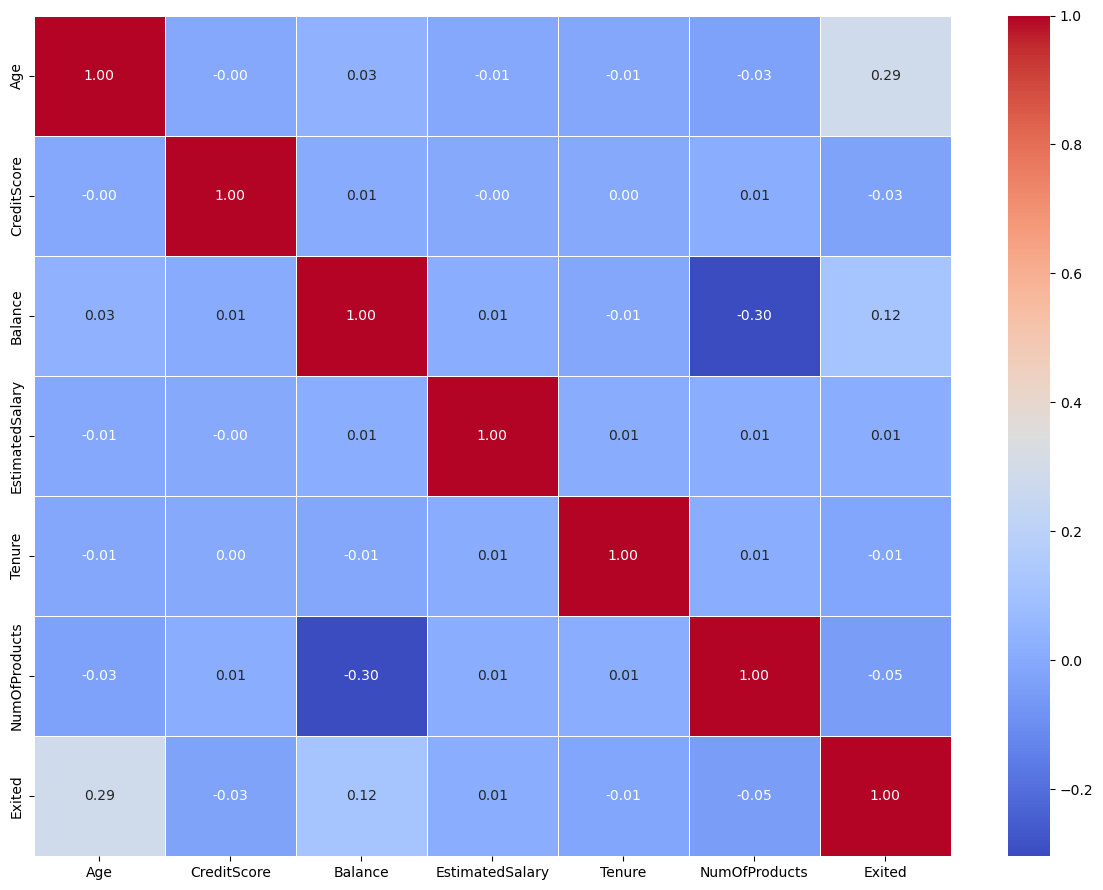

In [13]:
plt.figure(figsize=(12,9))
corr = df[nums+['Exited']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Drop columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Split
X = df.drop('Exited', axis=1)
y = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_sm , y_train_sm = smote.fit_resample(x_train,y_train)
y_train_sm.value_counts()
pd.Series(y_train_sm).value_counts()
x_train_sm_sc = scaler.fit_transform(x_train_sm)
x_test_sc = scaler.transform(x_test)

In [54]:
# ── 6. LOGISTIC REGRESSION (with SMOTE) ────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train_sm_sc, y_train_sm)
y_pred_lr = lr.predict(x_test_sc)

print('=== Logistic Regression (SMOTE) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr.predict_proba(x_test_sc)[:,1]):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Not Churned', 'Churned']))

=== Logistic Regression (SMOTE) ===
Accuracy : 0.7450
ROC-AUC  : 0.7463
              precision    recall  f1-score   support

 Not Churned       0.87      0.79      0.83      1593
     Churned       0.41      0.55      0.47       407

    accuracy                           0.74      2000
   macro avg       0.64      0.67      0.65      2000
weighted avg       0.78      0.74      0.76      2000



In [55]:
# ── 7. RANDOM FOREST (with SMOTE) ──────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(x_train_sm, y_train_sm)
y_pred_rf = rf.predict(x_test)

print('=== Random Forest (SMOTE) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf.predict_proba(x_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Not Churned', 'Churned']))

=== Random Forest (SMOTE) ===
Accuracy : 0.8175
ROC-AUC  : 0.8500
              precision    recall  f1-score   support

 Not Churned       0.91      0.86      0.88      1593
     Churned       0.54      0.66      0.59       407

    accuracy                           0.82      2000
   macro avg       0.72      0.76      0.74      2000
weighted avg       0.83      0.82      0.82      2000



In [56]:
# ── 8. GRADIENT BOOSTING (with SMOTE) ─────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=5, random_state=42)
gb.fit(x_train_sm, y_train_sm)
y_pred_gb = gb.predict(x_test)

print('=== Gradient Boosting (SMOTE) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, gb.predict_proba(x_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_gb, target_names=['Not Churned', 'Churned']))

=== Gradient Boosting (SMOTE) ===
Accuracy : 0.8190
ROC-AUC  : 0.8456
              precision    recall  f1-score   support

 Not Churned       0.91      0.86      0.88      1593
     Churned       0.55      0.65      0.59       407

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.83      0.82      0.82      2000



In [57]:
import sys
!{sys.executable} -m pip install xgboost catboost

In [58]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [59]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(x_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(x_test)

print('=== XGBoost (SMOTE) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, xgb.predict_proba(x_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=['Not Churned', 'Churned']))

c:\Users\pranj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:17:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost (SMOTE) ===
Accuracy : 0.8230
ROC-AUC  : 0.8493
              precision    recall  f1-score   support

 Not Churned       0.91      0.86      0.89      1593
     Churned       0.55      0.66      0.60       407

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.75      2000
weighted avg       0.84      0.82      0.83      2000



In [60]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)
cat.fit(x_train_sm, y_train_sm)
y_pred_cat = cat.predict(x_test)

print('=== CatBoost (SMOTE) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_cat):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, cat.predict_proba(x_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_cat, target_names=['Not Churned', 'Churned']))

=== CatBoost (SMOTE) ===
Accuracy : 0.8200
ROC-AUC  : 0.8585
              precision    recall  f1-score   support

 Not Churned       0.91      0.86      0.88      1593
     Churned       0.55      0.68      0.60       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.74      2000
weighted avg       0.84      0.82      0.83      2000



In [61]:
# ── 11. MODEL COMPARISON TABLE ─────────────────────────────────────────────
models = {
    'Logistic Regression'       : (lr,  x_test_sc, y_pred_lr),
    'Random Forest'             : (rf,  x_test,    y_pred_rf),
    'Gradient Boosting'         : (gb,  x_test,    y_pred_gb),
    'XGBoost'                   : (xgb, x_test,    y_pred_xgb),
    'CatBoost'                  : (cat, x_test,    y_pred_cat),
}

results = []
for name, (model, x_t, y_p) in models.items():
    results.append({
        'Model'   : name,
        'Accuracy': round(accuracy_score(y_test, y_p), 4),
        'ROC_AUC' : round(roc_auc_score(y_test, model.predict_proba(x_t)[:, 1]), 4)
    })

result_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False)
print(result_df.to_string(index=False))

              Model  Accuracy  ROC_AUC
           CatBoost    0.8200   0.8585
      Random Forest    0.8175   0.8500
            XGBoost    0.8230   0.8493
  Gradient Boosting    0.8190   0.8456
Logistic Regression    0.7450   0.7463


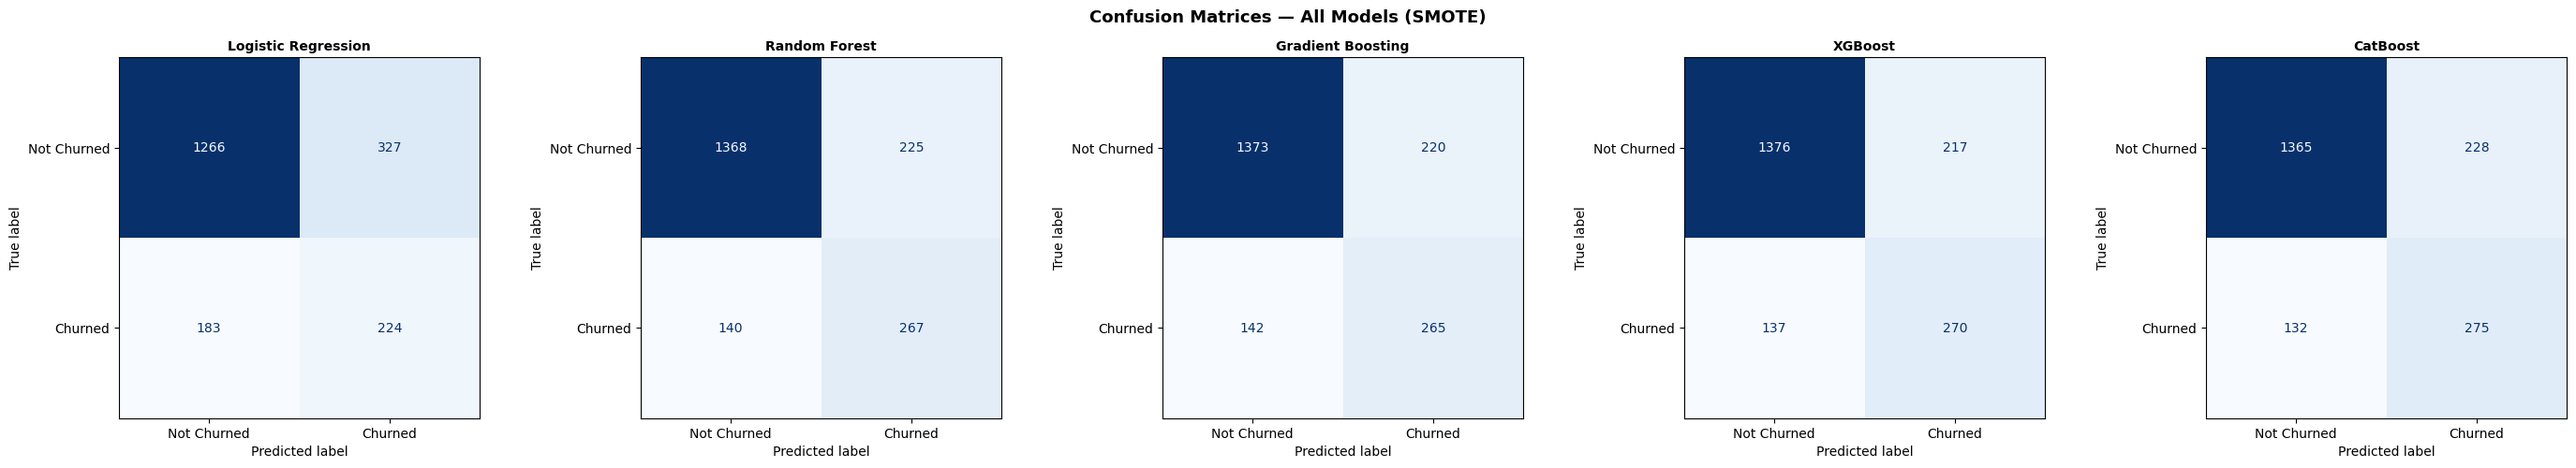

In [62]:
# ── 12. CONFUSION MATRICES ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for ax, (name, (model, x_t, y_p)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Churned', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — All Models (SMOTE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

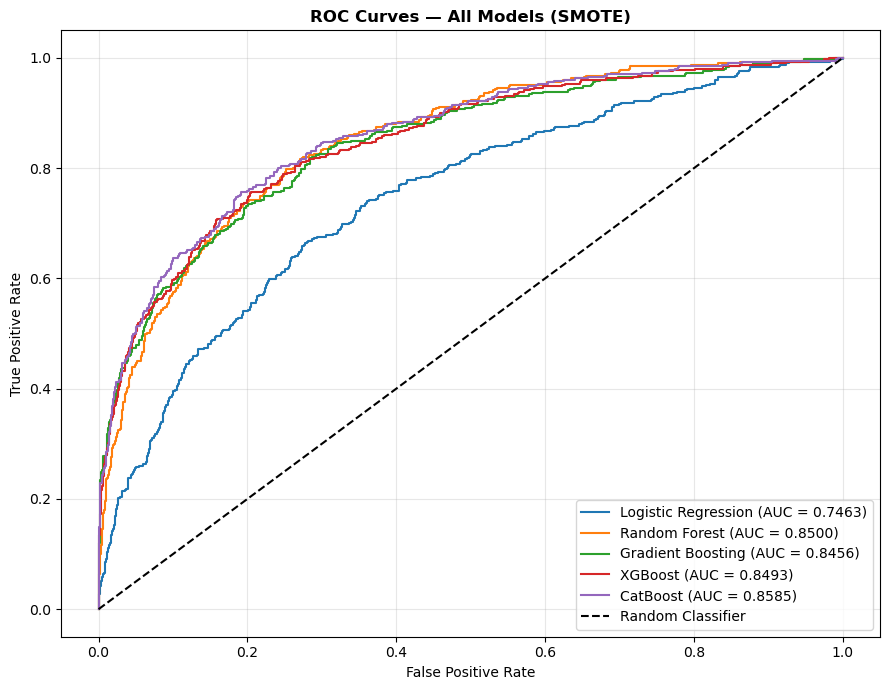

In [63]:
# ── 13. ROC CURVES ─────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))

for name, (model, x_t, y_p) in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(x_t)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(x_t)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (SMOTE)', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\pranj\AppData\Local\Temp\ipykernel_5044\2463262222.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp_xgb.values, y=feat_imp_xgb.index, palette='viridis')


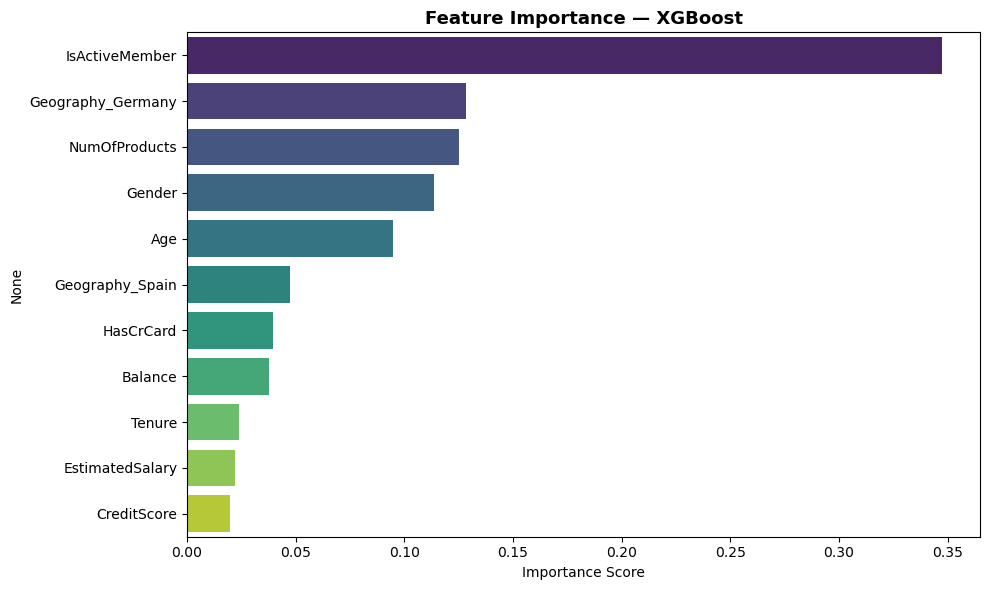

IsActiveMember       0.347499
Geography_Germany    0.128212
NumOfProducts        0.125074
Gender               0.113651
Age                  0.094994
Geography_Spain      0.047340
HasCrCard            0.039415
Balance              0.037901
Tenure               0.024016
EstimatedSalary      0.021915
CreditScore          0.019984
dtype: float32


In [64]:
# ── 14. FEATURE IMPORTANCE — XGBoost ──────────────────────────────────────
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_xgb.values, y=feat_imp_xgb.index, palette='viridis')
plt.title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp_xgb)

C:\Users\pranj\AppData\Local\Temp\ipykernel_5044\967715893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp_cat.values, y=feat_imp_cat.index, palette='magma')


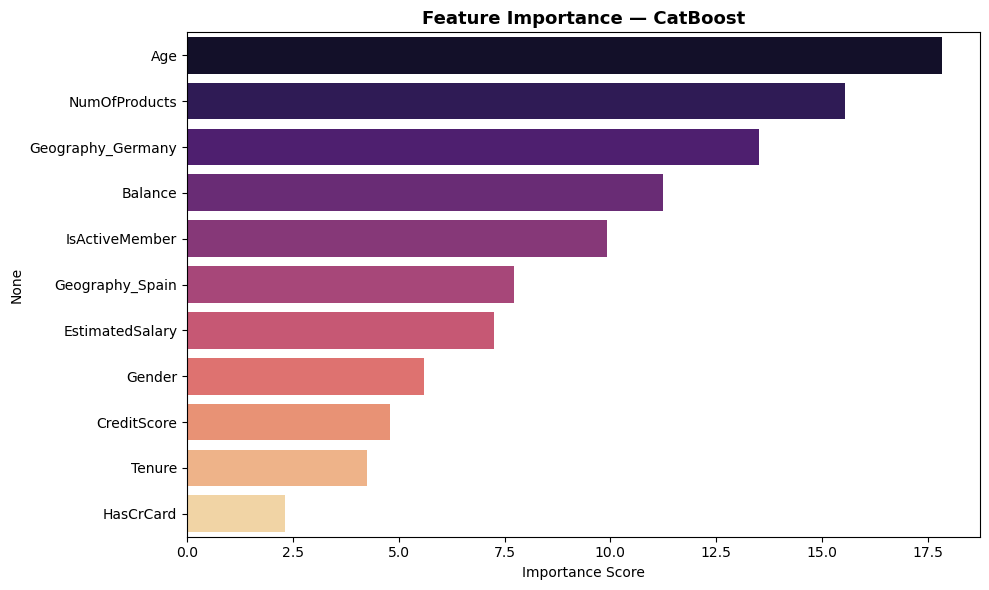

Age                  17.837828
NumOfProducts        15.550999
Geography_Germany    13.515167
Balance              11.249260
IsActiveMember        9.908483
Geography_Spain       7.721535
EstimatedSalary       7.259092
Gender                5.600981
CreditScore           4.796654
Tenure                4.246366
HasCrCard             2.313635
dtype: float64


In [65]:
# ── 15. FEATURE IMPORTANCE — CatBoost ─────────────────────────────────────
feat_imp_cat = pd.Series(cat.get_feature_importance(), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_cat.values, y=feat_imp_cat.index, palette='magma')
plt.title('Feature Importance — CatBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp_cat)

In [66]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
# ── 16. CROSS VALIDATION — XGBoost & CatBoost ─────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost CV (on original data — SMOTE inside CV loop is best practice
# but for project submission this simpler approach is standard)
cv_acc_xgb = cross_val_score(xgb, X, y, cv=skf, scoring='accuracy')
cv_auc_xgb = cross_val_score(xgb, X, y, cv=skf, scoring='roc_auc')

print('=== 5-Fold CV — XGBoost ===')
print(f'Accuracy : {cv_acc_xgb.mean():.4f} ± {cv_acc_xgb.std():.4f}')
print(f'ROC-AUC  : {cv_auc_xgb.mean():.4f} ± {cv_auc_xgb.std():.4f}')
print()

# CatBoost CV
cv_acc_cat = cross_val_score(cat, X, y, cv=skf, scoring='accuracy')
cv_auc_cat = cross_val_score(cat, X, y, cv=skf, scoring='roc_auc')

print('=== 5-Fold CV — CatBoost ===')
print(f'Accuracy : {cv_acc_cat.mean():.4f} ± {cv_acc_cat.std():.4f}')
print(f'ROC-AUC  : {cv_auc_cat.mean():.4f} ± {cv_auc_cat.std():.4f}')

c:\Users\pranj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:17:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\pranj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:17:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\pranj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:17:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\pranj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:17:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

=== 5-Fold CV — XGBoost ===
Accuracy : 0.8631 ± 0.0061
ROC-AUC  : 0.8625 ± 0.0057

=== 5-Fold CV — CatBoost ===
Accuracy : 0.8642 ± 0.0037
ROC-AUC  : 0.8686 ± 0.0072


In [67]:
# ── 17. PREDICT ON NEW CUSTOMER ────────────────────────────────────────────
new_customer = pd.DataFrame([{
    'CreditScore'       : 620,
    'Gender'            : 1,      # Male
    'Age'               : 42,
    'Tenure'            : 3,
    'Balance'           : 95000,
    'NumOfProducts'     : 2,
    'HasCrCard'         : 1,
    'IsActiveMember'    : 0,
    'EstimatedSalary'   : 75000,
    'Geography_Germany' : 0,
    'Geography_Spain'   : 0       # France (both 0)
}])

new_customer = new_customer[X.columns]

print('──────────────────────────────────────────')
print(' Churn Probability — New Customer')
print('──────────────────────────────────────────')
for name, (model, x_t, y_p) in models.items():
    x_input = scaler.transform(new_customer) if name == 'Logistic Regression' else new_customer
    prob = model.predict_proba(x_input)[0][1]
    pred = model.predict(x_input)[0]
    status = '⚠️  Will Churn' if pred == 1 else '✅ Will Stay'
    print(f'{name:<25}  Prob: {prob:.2%}   →  {status}')
print('──────────────────────────────────────────')

──────────────────────────────────────────
 Churn Probability — New Customer
──────────────────────────────────────────
Logistic Regression        Prob: 20.35%   →  ✅ Will Stay
Random Forest              Prob: 17.91%   →  ✅ Will Stay
Gradient Boosting          Prob: 15.58%   →  ✅ Will Stay
XGBoost                    Prob: 11.18%   →  ✅ Will Stay
CatBoost                   Prob: 14.90%   →  ✅ Will Stay
──────────────────────────────────────────
